In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

pl.Config.set_tbl_rows(-1)
pl.Config.set_decimal_separator(',')
pl.Config.set_thousands_separator('.')
pl.Config.set_float_precision(2)

DATA_SOURCE_1 = './../../DATA/Bolsa_Familia/'
DATA_SOURCE_2 = './../../DATA/TSE/'

##### Obtendo os dados e filtrando os registros 13 e 22

In [2]:
try:
    print('\nLendo os dados...')

    df_dados_bolsa = pl.scan_parquet(DATA_SOURCE_1 + 'bolsa_familia.parquet')
    print(df_dados_bolsa.columns)

    df_dados_votacao = pl.read_csv(DATA_SOURCE_2 + 'votacao_secao_2022_BR.csv', separator=';', encoding='iso-8859-1')
    print(df_dados_votacao.columns)

    # filtrar para segundo turno 'NR_TURNO' == 2 e 'NR_VOTAVEL' 13 e 22
    df_dados_votacao_turno2 = df_dados_votacao.filter(
        (pl.col('NR_TURNO') == 2) & 
        (pl.col('NR_VOTAVEL').is_in ([13, 22]))
    )


except Exception as e:
    print(f'\nErro ao ler os dados: {e}')


Lendo os dados...
['MÊS COMPETÊNCIA', 'MÊS REFERÊNCIA', 'UF', 'CÓDIGO MUNICÍPIO SIAFI', 'NOME MUNICÍPIO', 'CPF FAVORECIDO', 'NIS FAVORECIDO', 'NOME FAVORECIDO', 'VALOR PARCELA']


C:\Users\jairo.temerozo\AppData\Local\Temp\ipykernel_26956\129079265.py:5: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  print(df_dados_bolsa.columns)


['DT_GERACAO', 'HH_GERACAO', 'ANO_ELEICAO', 'CD_TIPO_ELEICAO', 'NM_TIPO_ELEICAO', 'NR_TURNO', 'CD_ELEICAO', 'DS_ELEICAO', 'DT_ELEICAO', 'TP_ABRANGENCIA', 'SG_UF', 'SG_UE', 'NM_UE', 'CD_MUNICIPIO', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'CD_CARGO', 'DS_CARGO', 'NR_VOTAVEL', 'NM_VOTAVEL', 'QT_VOTOS', 'NR_LOCAL_VOTACAO', 'SQ_CANDIDATO', 'NM_LOCAL_VOTACAO', 'DS_LOCAL_VOTACAO_ENDERECO']


##### Processando votação

In [3]:
try:
    # 1. Ativar o StringCache para gerenciar categorias de forma consistente no modo Lazy
    with pl.StringCache():
        
        # 2. Delimitar as colunas e aplicar as transformações de tipo de forma eficiente
        df_votacao = (
            df_dados_votacao_turno2.lazy()
            .select(['SG_UF', 'NM_VOTAVEL', 'QT_VOTOS'])
            .with_columns([
                pl.col('SG_UF').cast(pl.Categorical),
                pl.col('NM_VOTAVEL').cast(pl.Categorical)
            ])
            # 3. Agrupar, somar e ordenar
            .group_by(['SG_UF', 'NM_VOTAVEL'])
            .agg(pl.col('QT_VOTOS').sum().alias('QT_VOTOS_TOTAL'))
            .sort(['SG_UF', 'NM_VOTAVEL'])
            # 4. Executar e coletar de fato os dados para a memória
            .collect()
        )
        
    # Exibir os dados processados (fora do bloco StringCache)
    display(df_votacao)

except Exception as e:
    print(f'Erro ao processar os dados: {e}')

C:\Users\jairo.temerozo\AppData\Local\Temp\ipykernel_26956\463208879.py:3: DeprecationWarning: the string cache has been replaced by pl.Categories
  with pl.StringCache():


SG_UF,NM_VOTAVEL,QT_VOTOS_TOTAL
cat,cat,i64
"""AC""","""JAIR MESSIAS BOLSONARO""",287.750
"""AC""","""LUIZ INÁCIO LULA DA SILVA""",121.566
"""AL""","""JAIR MESSIAS BOLSONARO""",687.827
"""AL""","""LUIZ INÁCIO LULA DA SILVA""",976.831
"""AM""","""JAIR MESSIAS BOLSONARO""",961.741
"""AM""","""LUIZ INÁCIO LULA DA SILVA""",1.004.991
"""AP""","""JAIR MESSIAS BOLSONARO""",200.547
"""AP""","""LUIZ INÁCIO LULA DA SILVA""",189.918
"""BA""","""JAIR MESSIAS BOLSONARO""",2.357.028


##### Processando Bolsa Familia

In [4]:
# Processamento bolsa familia

try:
    # 1. Ativar o StringCache para gerenciar categorias de forma consistente no modo Lazy
    with pl.StringCache():
        
        # 2. Delimitar, converter, agrupar e ordenar os dados de forma eficiente
        df_bolsa_familia = (
            df_dados_bolsa.lazy()
            .select(['UF', 'VALOR PARCELA'])
            .with_columns([
                pl.col('UF').cast(pl.Categorical)
            ])
            # 3. Agrupar por 'UF' e somar o 'VALOR PARCELA'
            .group_by('UF')
            .agg(pl.col('VALOR PARCELA').sum().alias('VALOR_TOTAL'))
            .sort('UF')
            # 4. Executar o plano e coletar os dados para a memória
            .collect()
        )
        
    # Exibir os dados processados (fora do bloco StringCache)
    display(df_bolsa_familia)

except Exception as e:
    print(f'Erro ao processar os dados: {e}')

C:\Users\jairo.temerozo\AppData\Local\Temp\ipykernel_26956\3910503657.py:5: DeprecationWarning: the string cache has been replaced by pl.Categories
  with pl.StringCache():


UF,VALOR_TOTAL
cat,f64
"""AC""","445.278.628,00"
"""AL""","1.719.485.364,00"
"""AM""","2.173.681.249,00"
"""AP""","404.493.438,00"
"""BA""","7.775.720.895,00"
"""CE""","4.496.280.805,00"
"""DF""","532.890.182,00"
"""ES""","939.327.731,00"
"""GO""","1.486.309.200,00"


##### Juntando os dados

In [5]:
# Realizando o merge dos dois dataframes

try:
    # No Polars usamos o método .join() diretamente nos DataFrames coletados
    df_votos_bolsa_familia = (
        df_votacao.join(df_bolsa_familia, left_on='SG_UF', right_on='UF')
        .sort(['VALOR_TOTAL'], descending=True)
    )

    display(df_votos_bolsa_familia)

except Exception as e:
    print(f'Erro ao realizar o merge dos dados: {e}')

SG_UF,NM_VOTAVEL,QT_VOTOS_TOTAL,VALOR_TOTAL
cat,cat,i64,f64
"""BA""","""JAIR MESSIAS BOLSONARO""",2.357.028,"7.775.720.895,00"
"""BA""","""LUIZ INÁCIO LULA DA SILVA""",6.097.815,"7.775.720.895,00"
"""SP""","""JAIR MESSIAS BOLSONARO""",14.216.587,"7.450.021.108,00"
"""SP""","""LUIZ INÁCIO LULA DA SILVA""",11.519.882,"7.450.021.108,00"
"""PE""","""JAIR MESSIAS BOLSONARO""",1.798.832,"4.945.106.688,00"
"""PE""","""LUIZ INÁCIO LULA DA SILVA""",3.640.933,"4.945.106.688,00"
"""MG""","""JAIR MESSIAS BOLSONARO""",6.141.310,"4.755.366.777,00"
"""MG""","""LUIZ INÁCIO LULA DA SILVA""",6.190.960,"4.755.366.777,00"
"""RJ""","""JAIR MESSIAS BOLSONARO""",5.403.894,"4.740.470.130,00"


#### Correlação entre os dados

In [6]:
# verificando a correlação entre as variáveis 'QT_VOTOS_TOTAL' e 'VALOR_TOTAL'

try:
    dict_correlacoes = {} # guardar a correlação de cada candidato

    # Obter os candidatos únicos de forma limpa
    candidatos = df_votos_bolsa_familia['NM_VOTAVEL'].unique()

    print("Calculando correlações...\n" + "-"*50)

    for candidato in candidatos:
        # Filtrar dados do candidato e remover possíveis valores nulos nas colunas analisadas
        df_candidato = (
            df_votos_bolsa_familia
            .filter(pl.col('NM_VOTAVEL') == candidato)
            .drop_nulls(subset=['QT_VOTOS_TOTAL', 'VALOR_TOTAL'])
        )
        
        # Converter as colunas diretamente para arrays NumPy
        array_votos = df_candidato['QT_VOTOS_TOTAL'].to_numpy()
        array_bolsa_familia = df_candidato['VALOR_TOTAL'].to_numpy()

        # Verificar se há dados suficientes para calcular a correlação (mínimo 2 pontos)
        if len(array_votos) > 1:
            # Calcular a matriz de correlação de Pearson
            correlacao = np.corrcoef(array_votos, array_bolsa_familia)[0, 1]
            
            # Se o desvio padrão de algum array for zero, o corrcoef retorna NaN
            if np.isnan(correlacao):
                print(f'⚠️ {candidato}: Não foi possível calcular (dados constantes).')
                dict_correlacoes[candidato] = 0.0
            else:
                dict_correlacoes[candidato] = correlacao
                print(f'➡️ Correlação para {candidato:.<30} r = {correlacao:+.4f}')
        else:
            print(f'⚠️ {candidato}: Dados insuficientes para calcular correlação.')

    print("-"*50 + '\nProcesso concluído com sucesso!')

except Exception as e:
    print(f'Erro ao calcular a correlação: {e}')

Calculando correlações...
--------------------------------------------------
➡️ Correlação para JAIR MESSIAS BOLSONARO........ r = +0.6328
➡️ Correlação para LUIZ INÁCIO LULA DA SILVA..... r = +0.8908
--------------------------------------------------
Processo concluído com sucesso!


#### Visualizando os dados


Plotando os gráficos...


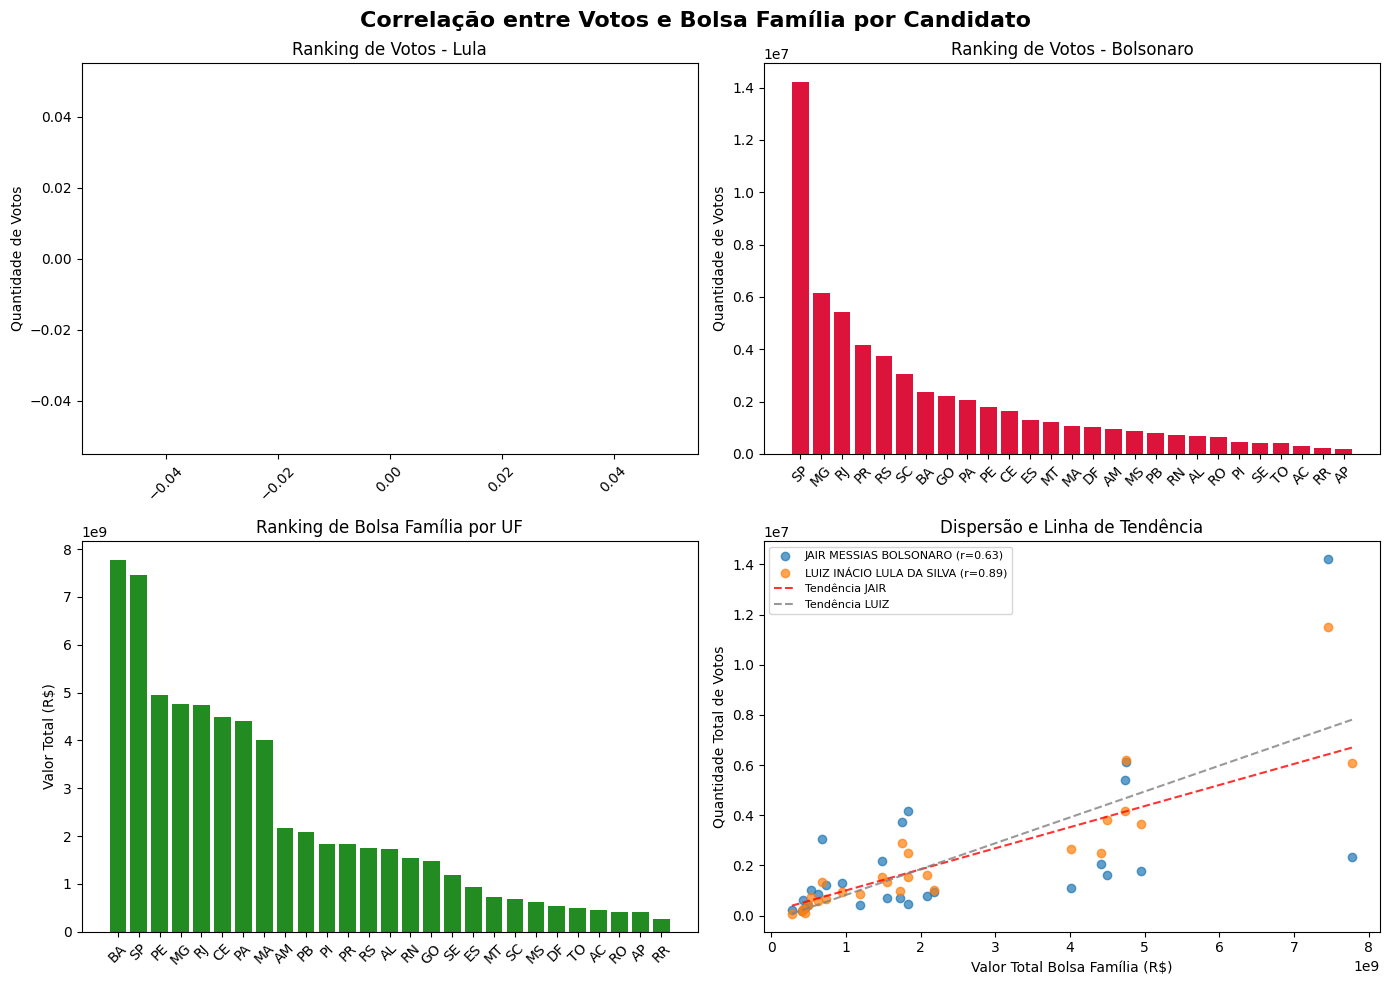

In [ ]:
# visualização dos dados

try:
    print('\nPlotando os gráficos...')

    # Criar a figura principal com um tamanho adequado para 4 gráficos
    plt.figure(figsize=(16, 12))
    plt.suptitle('Correlação entre Votos e Bolsa Família por Candidato', fontsize=16, fontweight='bold', y=0.98)

    # --- Posição 1: Ranking Lula ---
    plt.subplot(2, 2, 1)
    df_lula = df_votacao.filter(pl.col('NM_VOTAVEL').str.contains('LULA'))
    df_lula = df_lula.sort('QT_VOTOS_TOTAL', descending=True)

    plt.bar(df_lula['SG_UF'], df_lula['QT_VOTOS_TOTAL'], color='royalblue')
    plt.title('Ranking de Votos - Lula')
    plt.ylabel('Quantidade de Votos')
    plt.xticks(rotation=45)  # Rotaciona para evitar que as UFs se sobreponham

    # --- Posição 2: Ranking Bolsonaro ---
    plt.subplot(2, 2, 2)
    df_bolsonaro = df_votacao.filter(pl.col('NM_VOTAVEL').str.contains('JAIR'))
    df_bolsonaro = df_bolsonaro.sort('QT_VOTOS_TOTAL', descending=True)

    plt.bar(df_bolsonaro['SG_UF'], df_bolsonaro['QT_VOTOS_TOTAL'], color='crimson')
    plt.title('Ranking de Votos - Bolsonaro')
    plt.ylabel('Quantidade de Votos')
    plt.xticks(rotation=45)

    # --- Posição 3: Ranking Bolsa Família ---
    plt.subplot(2, 2, 3)
    df_bolsa_familia_sorted = df_bolsa_familia.sort('VALOR_TOTAL', descending=True)

    plt.bar(df_bolsa_familia_sorted['UF'], df_bolsa_familia_sorted['VALOR_TOTAL'], color='forestgreen')
    plt.title('Ranking de Bolsa Família por UF')
    plt.ylabel('Valor Total (R$)')
    plt.xticks(rotation=45)

    # --- Posição 4: Correlação entre Votos e Bolsa Família ---
    plt.subplot(2, 2, 4)
    plt.title('Dispersão e Linha de Tendência')

    # 1. Gráfico de dispersão (Scatter)
    for candidato, correlacao in dict_correlacoes.items():
        df_candidato = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == candidato)
        plt.scatter(
            df_candidato['VALOR_TOTAL'], 
            df_candidato['QT_VOTOS_TOTAL'], 
            label=f'{candidato} (r={correlacao:.2f})',
            alpha=0.7
        )

    # 2. Linhas de tendência
    cores_tendencia = {'LUIS INÁCIO LULA DA SILVA': 'royalblue', 'JAIR MESSIAS BOLSONARO': 'crimson'} # Exemplo de mapeamento de cores para as linhas
    for candidato in df_votos_bolsa_familia['NM_VOTAVEL'].unique():
        df_candidato = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == candidato)
        x = np.array(df_candidato['VALOR_TOTAL'])
        y = np.array(df_candidato['QT_VOTOS_TOTAL'])
        
        # polyfit para calcular a regressão linear simples
        m, b = np.polyfit(x, y, 1)
        
        # Ordena o eixo X para que a linha seja traçada corretamente do início ao fim
        x_plot = np.sort(x)
        color = cores_tendencia.get(candidato, 'gray')
        plt.plot(x_plot, m*x_plot + b, linestyle='--', color=color, alpha=0.8, label=f'Tendência {candidato.split()[0]}')

    # Configurações do quadrante 4 (chamadas após criar todos os elementos do plot)
    plt.xlabel('Valor Total Bolsa Família (R$)')
    plt.ylabel('Quantidade Total de Votos')
    plt.legend(fontsize=8, loc='best')

    # Ajustar o espaçamento para que nenhum título ou eixo fique cortado
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f'Erro ao visualizar os dados: {e}')